# Modelo NORTE NO2

In [33]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


PyTorch version: 2.6.0
CUDA available: False
CUDA device count: 0


In [34]:
from utils import logistic_model_station, analyze_logistic_model, recalibrate_threshold, plot_recalibration
import pandas as pd

In [35]:
# Configuración GPU - Verificar disponibilidad de CUDA
import torch

# Verificar si CUDA está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Dispositivo seleccionado: {device}")

if torch.cuda.is_available():
    print(f"🎮 GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"📊 Memoria GPU total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"🚀 Versión CUDA: {torch.version.cuda}")
else:
    print("⚠️  CUDA no disponible, usando CPU")

🔥 Dispositivo seleccionado: cpu
⚠️  CUDA no disponible, usando CPU


In [36]:
def monitor_gpu_usage():
    """
    Monitorea el uso de memoria GPU durante el entrenamiento.
    """
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / 1e9
        reserved = torch.cuda.memory_reserved(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        print(f"📊 MEMORIA GPU:")
        print(f"  • Asignada: {allocated:.2f} GB")
        print(f"  • Reservada: {reserved:.2f} GB")
        print(f"  • Total: {total:.2f} GB")
        print(f"  • Libre: {total - reserved:.2f} GB")
        print(f"  • Uso: {(reserved/total)*100:.1f}%")
    else:
        print("⚠️ GPU no disponible para monitoreo")

In [37]:
# load dfs
dfs = {}
names = [
    "NORESTE", "NORTE"
]

for name in names:
    dfs[name] = pd.read_csv(f"datos/datosLimpios/estacion_{name.lower()}.csv")

# Add one hot encoded hour to each dataframe from Date column
for name in names:
    dfs[name]['Date'] = pd.to_datetime(dfs[name]['Date'])
    hour_dummies = pd.get_dummies(dfs[name]['Date'].dt.hour, prefix='hour', drop_first=True)
    dfs[name] = pd.concat([dfs[name], hour_dummies], axis=1)


In [38]:
dfs["NORESTE"].head()

,Date,NORESTE CO ppm,NORESTE NO ppb,NORESTE NO2 ppb,NORESTE NOX ppb,NORESTE O3 ppb,NORESTE PM10 ug/m3,NORESTE PM2.5 ug/m3,NORESTE PRS mmhg,NORESTE RAINF mm/hr,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2023-01-01 00:00:00,3.40,30.4,43.0,73.4,7.0,222.0,55.4,718.4,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2023-01-01 01:00:00,4.30,67.2,44.4,111.6,8.0,311.0,280.0,718.1,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-01 02:00:00,4.28,63.9,41.5,105.5,7.0,723.0,400.0,717.8,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-01 03:00:00,3.77,57.2,42.3,99.5,6.0,473.0,349.0,717.6,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 04:00:00,2.98,41.9,39.9,81.8,5.0,372.0,260.0,717.6,0.0,...,False,False,False,False,False,False,False,False,False,False


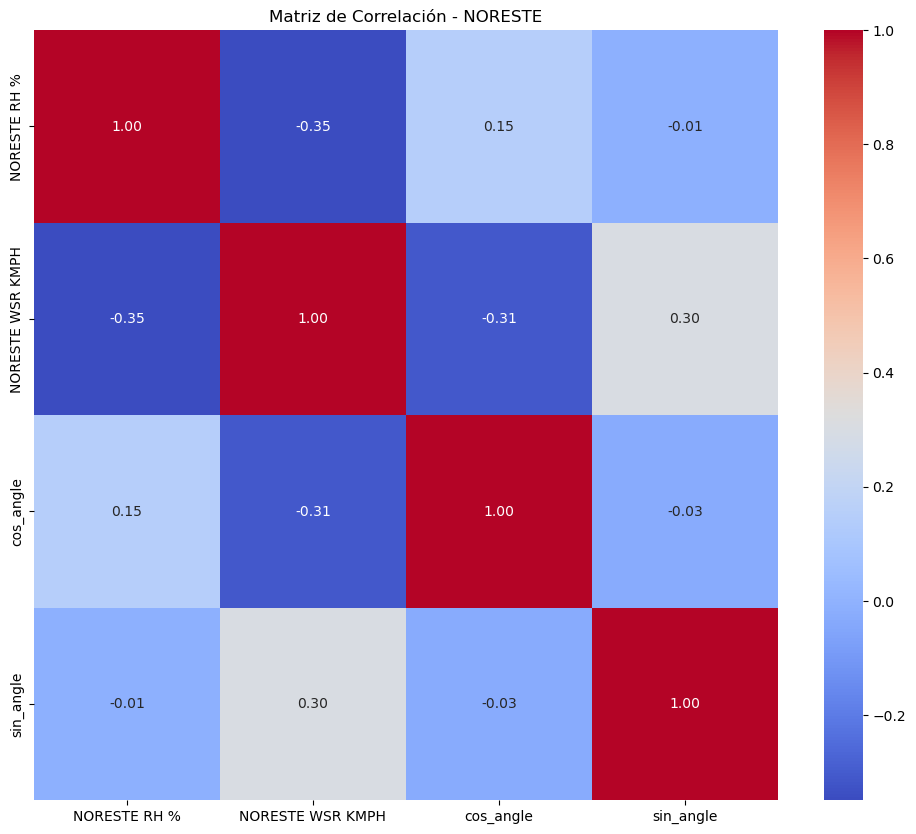

In [39]:
# agregar columnas con coseno y seno de las columna 15
import numpy as np
dfs["NORESTE"]['cos_angle'] = np.cos(np.pi/180 * dfs["NORESTE"]['NORESTE WDV DEG'])
dfs["NORESTE"]['sin_angle'] = np.sin(np.pi/180 *dfs["NORESTE"]['NORESTE WDV DEG'])

dfs["NORTE"]['cos_angle'] = np.cos(np.pi/180 *dfs["NORTE"]['NORTE WDV DEG'])
dfs["NORTE"]['sin_angle'] = np.sin(np.pi/180 *dfs["NORTE"]['NORTE WDV DEG'])

# Correlacion entre variables predictoras (10, 14, 16-fin)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
corr = dfs["NORESTE"].iloc[:, [10, 14]]
corr = pd.concat([corr, dfs["NORESTE"].iloc[:, -2:]], axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación - NORESTE")
plt.show()



In [40]:
# Ejemplo de uso para la estacion NORTE
model_norte, report_norte = logistic_model_station(
    df=dfs["NORTE"],
    contaminant_idx=3,
    wind_dir_idx=15,
    wind_speed_idx=14,
    rh_idx=10,
    # temp_idx=13,
    # backward_selection=True,
)


🕒 Agregadas 23 características de hora
Umbral crítico: 31.200
Variables utilizadas en el modelo: ['Wind_sin', 'Wind_cos', 'Wind_Speed', 'Humidity', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6', 'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12', 'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18', 'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23']
Distribución de la variable objetivo: {0: 19084, 1: 2128}


In [41]:
summary_norte = analyze_logistic_model(model_norte, report_norte)



📊 RESUMEN DEL MODELO LOGÍSTICO
                           Logit Regression Results                           
Dep. Variable:               Critical   No. Observations:                14848
Model:                          Logit   Df Residuals:                    14820
Method:                           MLE   Df Model:                           27
Date:                Sat, 13 Sep 2025   Pseudo R-squ.:                  0.2028
Time:                        22:49:49   Log-Likelihood:                -3856.8
converged:                       True   LL-Null:                       -4838.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9738      0.140      6.971      0.000       0.700       1.248
Wind_sin      -0.4492      0.059     -7.668      0.000      -0.564      -0.334
Wind_cos       0.153

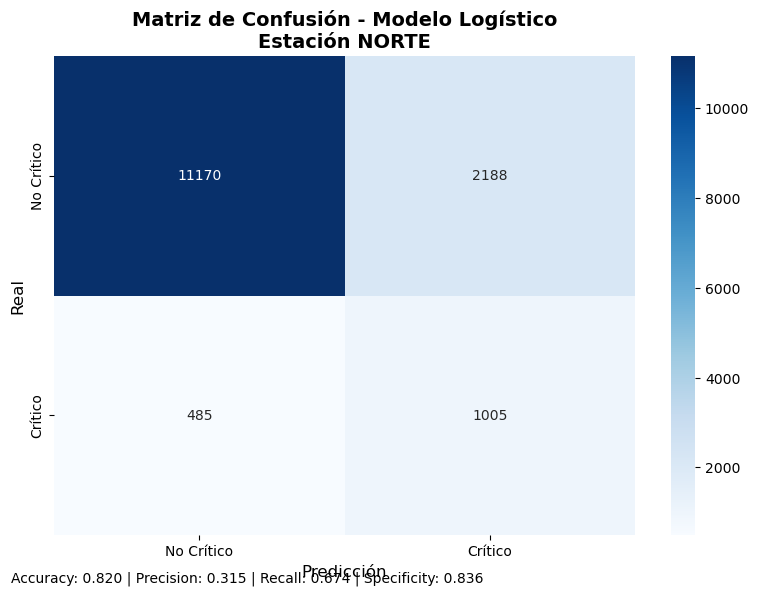

📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 11170 - Correctamente clasificados como No Críticos
Falsos Positivos (FP): 2188 - Incorrectamente clasificados como Críticos
Falsos Negativos (FN): 485 - Incorrectamente clasificados como No Críticos
Verdaderos Positivos (TP): 1005 - Correctamente clasificados como Críticos

📈 MÉTRICAS:
Accuracy (Exactitud): 0.820
Precision (Precisión): 0.315
Recall (Sensibilidad): 0.674
Specificity (Especificidad): 0.836


In [42]:
# Grafico matriz de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Obtener datos del modelo
y_test = model_norte.model.endog  # valores reales
X_test = model_norte.model.exog   # características de test

# Probabilidades predichas
y_probs = model_norte.predict(X_test)

# Convertir probabilidades a predicciones binarias (umbral 0.5)
y_pred = (y_probs >= 0.15).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Crítico', 'Crítico'], 
            yticklabels=['No Crítico', 'Crítico'])

plt.title('Matriz de Confusión - Modelo Logístico\nEstación NORTE', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

# Añadir estadísticas adicionales
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

plt.figtext(0.02, 0.02, 
           f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | '
           f'Recall: {recall:.3f} | Specificity: {specificity:.3f}',
           fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print("📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("=" * 50)
print(f"Verdaderos Negativos (TN): {tn} - Correctamente clasificados como No Críticos")
print(f"Falsos Positivos (FP): {fp} - Incorrectamente clasificados como Críticos")
print(f"Falsos Negativos (FN): {fn} - Incorrectamente clasificados como No Críticos")
print(f"Verdaderos Positivos (TP): {tp} - Correctamente clasificados como Críticos")
print(f"\n📈 MÉTRICAS:")
print(f"Accuracy (Exactitud): {accuracy:.3f}")
print(f"Precision (Precisión): {precision:.3f}")
print(f"Recall (Sensibilidad): {recall:.3f}")
print(f"Specificity (Especificidad): {specificity:.3f}")

    Threshold  Precision    Recall        F1
0        0.05   0.171819  0.895302  0.288308
1        0.10   0.248108  0.791946  0.377842
2        0.15   0.314751  0.674497  0.429212
3        0.20   0.370632  0.562416  0.446814
4        0.25   0.411295  0.449664  0.429625
5        0.30   0.426330  0.328188  0.370876
6        0.35   0.443250  0.248993  0.318865
7        0.40   0.443124  0.175168  0.251082
8        0.45   0.460094  0.131544  0.204593
9        0.50   0.466899  0.089933  0.150816
10       0.55   0.511236  0.061074  0.109113
11       0.60   0.560000  0.037584  0.070440
12       0.65   0.529412  0.018121  0.035042
13       0.70   0.576923  0.010067  0.019789
14       0.75   0.500000  0.002685  0.005340
15       0.80   0.000000  0.000000  0.000000
16       0.85   0.000000  0.000000  0.000000
17       0.90   0.000000  0.000000  0.000000
18       0.95   0.000000  0.000000  0.000000


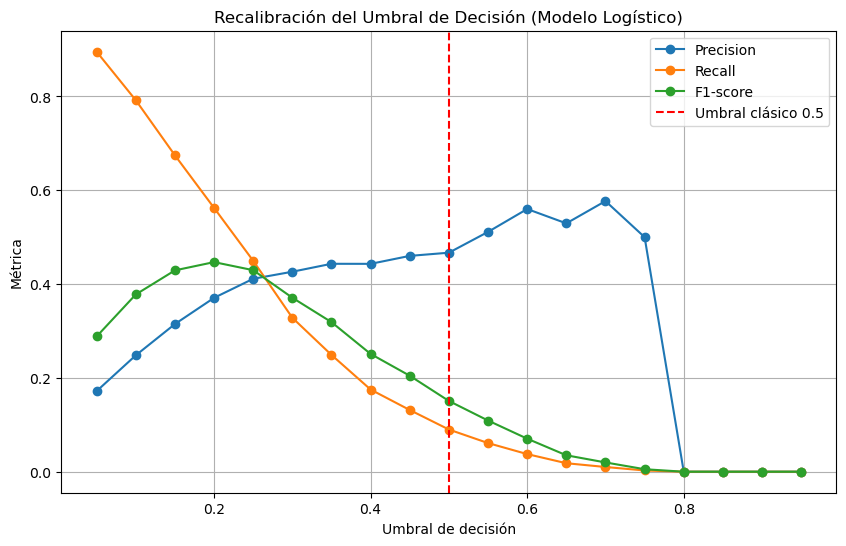

⚡ Mejor umbral encontrado según F1: 0.20


In [43]:
y_test = model_norte.model.endog
X_test = model_norte.model.exog

# Probabilidades predichas correctamente
y_probs_test = model_norte.predict(X_test)

# Barrido de umbrales
results_df = recalibrate_threshold(y_test, y_probs_test, step=0.05)

# Mostrar tabla
print(results_df)

# Graficar
plot_recalibration(results_df)

# Umbral óptimo según F1
best_idx = results_df["F1"].idxmax()
best_threshold = results_df.loc[best_idx, "Threshold"]
print(f"⚡ Mejor umbral encontrado según F1: {best_threshold:.2f}")

# MODELO NORESTE PM2.5

In [44]:
# Ejemplo de uso para la estacion NORTE

model_noreste, report_noreste = logistic_model_station(
    df=dfs["NORESTE"],
    contaminant_idx=7,
    wind_dir_idx=15,
    wind_speed_idx=14,
    rh_idx=10,
    # temp_idx=13,
    threshold=33
)


🕒 Agregadas 23 características de hora
Umbral crítico: 33.000
Variables utilizadas en el modelo: ['Wind_sin', 'Wind_cos', 'Wind_Speed', 'Humidity', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6', 'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12', 'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18', 'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23']
Distribución de la variable objetivo: {0: 18248, 1: 2964}


In [45]:
summary_norte = analyze_logistic_model(model_noreste, report_noreste)


📊 RESUMEN DEL MODELO LOGÍSTICO
                           Logit Regression Results                           
Dep. Variable:               Critical   No. Observations:                14848
Model:                          Logit   Df Residuals:                    14820
Method:                           MLE   Df Model:                           27
Date:                Sat, 13 Sep 2025   Pseudo R-squ.:                 0.07216
Time:                        22:49:50   Log-Likelihood:                -5572.7
converged:                       True   LL-Null:                       -6006.1
Covariance Type:            nonrobust   LLR p-value:                3.318e-165
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6828      0.164     -4.156      0.000      -1.005      -0.361
Wind_sin      -0.2826      0.044     -6.452      0.000      -0.368      -0.197
Wind_cos       0.049

    Threshold  Precision    Recall        F1
0        0.05   0.150338  0.943614  0.259355
1        0.10   0.189482  0.809157  0.307059
2        0.15   0.238503  0.657349  0.350013
3        0.20   0.286573  0.482410  0.359555
4        0.25   0.326776  0.288193  0.306274
5        0.30   0.369845  0.138313  0.201333
6        0.35   0.439834  0.051084  0.091537
7        0.40   0.471698  0.012048  0.023496
8        0.45   0.461538  0.002892  0.005747
9        0.50   0.750000  0.001446  0.002886
10       0.55   1.000000  0.000482  0.000963
11       0.60   0.000000  0.000000  0.000000
12       0.65   0.000000  0.000000  0.000000
13       0.70   0.000000  0.000000  0.000000
14       0.75   0.000000  0.000000  0.000000
15       0.80   0.000000  0.000000  0.000000
16       0.85   0.000000  0.000000  0.000000
17       0.90   0.000000  0.000000  0.000000
18       0.95   0.000000  0.000000  0.000000


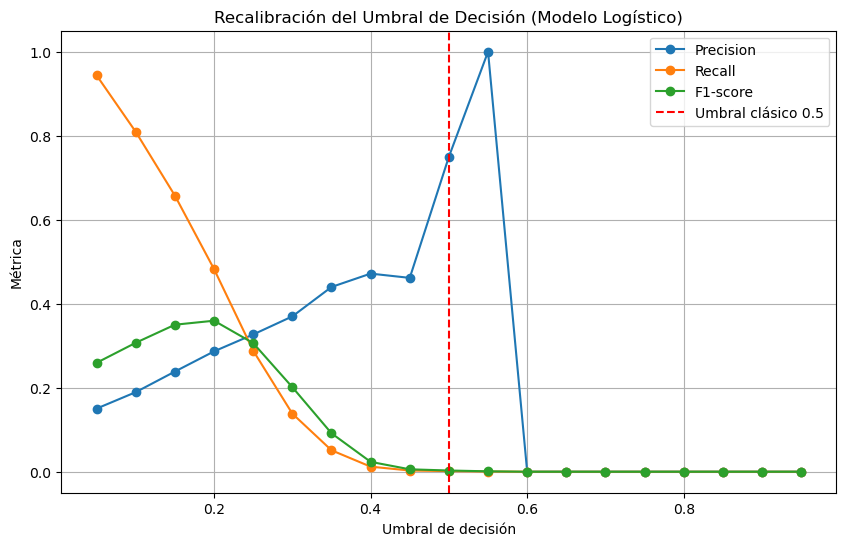

⚡ Mejor umbral encontrado según F1: 0.20


In [46]:
y_test = model_noreste.model.endog
X_test = model_noreste.model.exog

# Probabilidades predichas correctamente
y_probs_test = model_noreste.predict(X_test)

# Barrido de umbrales
results_df2 = recalibrate_threshold(y_test, y_probs_test, step=0.05)

# Mostrar tabla
print(results_df2)

# Graficar
plot_recalibration(results_df2)

# Umbral óptimo según F1
best_idx = results_df2["F1"].idxmax()
best_threshold = results_df2.loc[best_idx, "Threshold"]
print(f"⚡ Mejor umbral encontrado según F1: {best_threshold:.2f}")

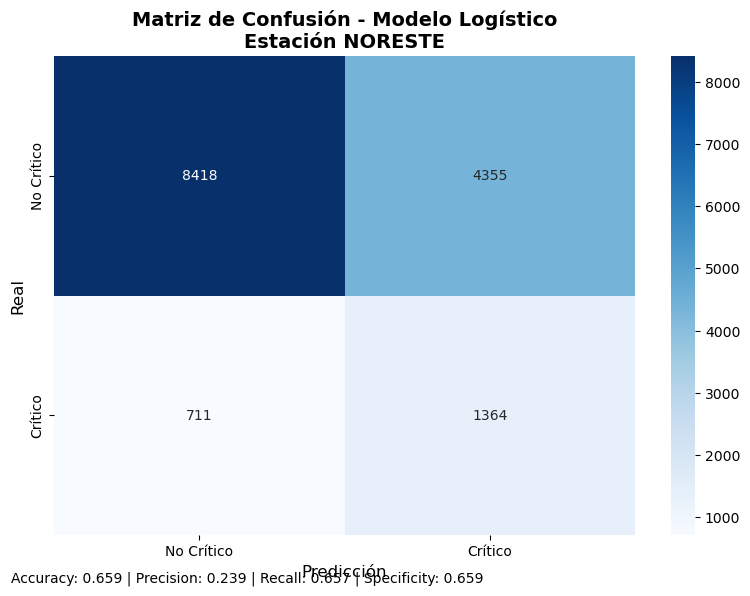

📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 8418 - Correctamente clasificados como No Críticos
Falsos Positivos (FP): 4355 - Incorrectamente clasificados como Críticos
Falsos Negativos (FN): 711 - Incorrectamente clasificados como No Críticos
Verdaderos Positivos (TP): 1364 - Correctamente clasificados como Críticos

📈 MÉTRICAS:
Accuracy (Exactitud): 0.659
Precision (Precisión): 0.239
Recall (Sensibilidad): 0.657
Specificity (Especificidad): 0.659


In [47]:
# Grafico matriz de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Obtener datos del modelo
y_test = model_noreste.model.endog  # valores reales
X_test = model_noreste.model.exog   # características de test

# Probabilidades predichas
y_probs = model_noreste.predict(X_test)

# Convertir probabilidades a predicciones binarias (umbral 0.5)
y_pred = (y_probs >= 0.15).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Crítico', 'Crítico'], 
            yticklabels=['No Crítico', 'Crítico'])

plt.title('Matriz de Confusión - Modelo Logístico\nEstación NORESTE', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

# Añadir estadísticas adicionales
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

plt.figtext(0.02, 0.02, 
           f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | '
           f'Recall: {recall:.3f} | Specificity: {specificity:.3f}',
           fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print("📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("=" * 50)
print(f"Verdaderos Negativos (TN): {tn} - Correctamente clasificados como No Críticos")
print(f"Falsos Positivos (FP): {fp} - Incorrectamente clasificados como Críticos")
print(f"Falsos Negativos (FN): {fn} - Incorrectamente clasificados como No Críticos")
print(f"Verdaderos Positivos (TP): {tp} - Correctamente clasificados como Críticos")
print(f"\n📈 MÉTRICAS:")
print(f"Accuracy (Exactitud): {accuracy:.3f}")
print(f"Precision (Precisión): {precision:.3f}")
print(f"Recall (Sensibilidad): {recall:.3f}")
print(f"Specificity (Especificidad): {specificity:.3f}")

# MODELO RED NEURONAL - PyTorch

Implementación de una red neuronal para clasificación binaria usando PyTorch. 
Este modelo será compatible con las funciones de evaluación existentes.

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [49]:
class BinaryClassificationNet(nn.Module):
    """
    Red neuronal estándar para clasificación binaria con soporte GPU.
    Arquitectura: Input -> Hidden1 -> Dropout -> Hidden2 -> Dropout -> Output
    """
    def __init__(self, input_size, hidden1_size=64, hidden2_size=128, dropout_rate=0.2):
        super(BinaryClassificationNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, 1),
            nn.Sigmoid()  # Para probabilidades entre 0 y 1
        )
    
    def forward(self, x):
        return self.network(x)

    def predict_proba(self, X):
        """
        Método para compatibilidad con sklearn - devuelve probabilidades
        Optimizado para GPU
        """
        device = next(self.parameters()).device  # Obtener device del modelo
        self.eval()
        with torch.no_grad():
            if isinstance(X, np.ndarray):
                X = torch.FloatTensor(X).to(device)
            elif not X.is_cuda and device.type == 'cuda':
                X = X.to(device)
            probabilities = self.forward(X).cpu().numpy().flatten()
        return probabilities
    
    def predict(self, X, threshold=0.5):
        """
        Método para compatibilidad con sklearn - devuelve predicciones binarias
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [50]:
def find_optimal_threshold(y_true, y_probs, min_recall=0.7, step=0.01):
    """
    Encuentra el threshold que maximiza F1 manteniendo recall mínimo.
    
    Parámetros:
    - min_recall: Recall mínimo requerido para clase crítica
    - step: Paso para búsqueda de threshold
    """
    from sklearn.metrics import precision_recall_fscore_support
    
    best_threshold = 0.5
    best_f1 = 0
    
    thresholds = np.arange(0.05, 0.95, step)
    
    results = []
    
    for threshold in thresholds:
        y_pred = (y_probs >= threshold).astype(int)
        
        if len(np.unique(y_pred)) < 2:  # Skip si solo predice una clase
            continue
            
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0
        )
        
        # Solo considerar si recall de clase crítica >= min_recall
        if len(recall) > 1 and recall[1] >= min_recall:
            if f1[1] > best_f1:  # F1 de clase crítica
                best_f1 = f1[1]
                best_threshold = threshold
        
        results.append({
            'threshold': threshold,
            'precision_0': precision[0] if len(precision) > 0 else 0,
            'recall_0': recall[0] if len(recall) > 0 else 0,
            'f1_0': f1[0] if len(f1) > 0 else 0,
            'precision_1': precision[1] if len(precision) > 1 else 0,
            'recall_1': recall[1] if len(recall) > 1 else 0,
            'f1_1': f1[1] if len(f1) > 1 else 0,
        })
    
    print(f"🎯 Threshold óptimo encontrado: {best_threshold:.3f}")
    print(f"   Con F1 de clase crítica: {best_f1:.3f}")
    print(f"   Garantizando recall mínimo: {min_recall:.1%}")
    
    return best_threshold

In [51]:
class FocalLoss(nn.Module):
    """
    Focal Loss para clases desbalanceadas - más suave que weighted BCE.
    Se enfoca en ejemplos difíciles sin penalizar tanto los fáciles.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)  # pt = p si y=1, pt = 1-p si y=0
        
        # Alpha balancing
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        # Focal weight
        focal_weight = alpha_t * (1 - pt) ** self.gamma
        
        focal_loss = focal_weight * bce_loss
        return focal_loss.mean()

def neural_model_station(
    df,
    contaminant_idx,
    wind_dir_idx=None,
    wind_speed_idx=None,
    rh_idx=None,
    temp_idx=None,
    threshold=None,
    hidden1_size=64,
    hidden2_size=32,
    dropout_rate=0.2,
    learning_rate=0.001,
    epochs=100,
    batch_size=32,
    focal_alpha=0.25,  # Peso para clase positiva (crítica)
    focal_gamma=2.0,   # Factor de enfoque en ejemplos difíciles
    min_recall=0.7,    # Recall mínimo más realista
    include_hour_features=True,  # Nuevo parámetro para incluir horas
    verbose=True
):
    """
    Red neuronal con Focal Loss - balanceado más suave.
    Ahora incluye las características de hora del día (one-hot encoded).
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if verbose:
        print(f"🎮 Usando dispositivo: {device}")
    
    contaminant_col = df.columns[contaminant_idx]
    
    # Preparar variables básicas
    feature_cols = []
    feature_names = []
    data_cols = [contaminant_col]
    
    if wind_dir_idx is not None:
        wind_col = df.columns[wind_dir_idx]
        data_cols.append(wind_col)
        feature_names.extend(["Wind_sin", "Wind_cos"])
    
    if wind_speed_idx is not None:
        speed_col = df.columns[wind_speed_idx]
        data_cols.append(speed_col)
        feature_cols.append(speed_col)
        feature_names.append("Wind_Speed")
    
    if rh_idx is not None:
        rh_col = df.columns[rh_idx]
        data_cols.append(rh_col)
        feature_cols.append(rh_col)
        feature_names.append("Humidity")
    
    if temp_idx is not None:
        temp_col = df.columns[temp_idx]
        data_cols.append(temp_col)
        feature_cols.append(temp_col)
        feature_names.append("Temperature")

    # 🕒 Agregar columnas de horas (one-hot encoded)
    hour_cols = []
    if include_hour_features:
        # Buscar columnas que empiecen con 'hour_'
        hour_cols = [col for col in df.columns if col.startswith('hour_')]
        if hour_cols:
            data_cols.extend(hour_cols)
            feature_cols.extend(hour_cols)
            feature_names.extend([f"Hour_{col.split('_')[1]}" for col in hour_cols])
            if verbose:
                print(f"🕒 Agregadas {len(hour_cols)} características de hora")
        else:
            if verbose:
                print("⚠️ No se encontraron columnas de hora (hour_*)")

    if len(data_cols) == 1:
        raise ValueError("Debe proporcionar al menos una variable predictora")

    data = df[data_cols].dropna()
    if data.empty:
        raise ValueError("No hay datos suficientes después de eliminar NaN")

    if threshold is None:
        threshold = np.percentile(data[contaminant_col], 90)
    if verbose:
        print(f"Umbral crítico: {threshold:.3f}")

    data["Critical"] = (data[contaminant_col] >= threshold).astype(int)

    # Construir matriz de características
    X_data = []
    
    # Variables de viento (sin y cos)
    if wind_dir_idx is not None:
        wind_rad = np.deg2rad(data[wind_col] % 360)
        X_data.append(np.sin(wind_rad))
        X_data.append(np.cos(wind_rad))
    
    # Variables continuas (velocidad viento, humedad, temperatura)
    for col in feature_cols:
        if col not in hour_cols:  # Excluir las columnas de hora para procesarlas por separado
            X_data.append(data[col].values)
    
    # 🕒 Agregar variables de hora (ya están one-hot encoded)
    if include_hour_features and hour_cols:
        for hour_col in hour_cols:
            X_data.append(data[hour_col].values)
    
    X = np.column_stack(X_data)
    y = data["Critical"].values

    if len(np.unique(y)) < 2:
        raise ValueError("La variable objetivo no tiene variabilidad")

    class_counts = np.bincount(y)
    
    if verbose:
        print(f"Variables utilizadas: {feature_names}")
        print(f"Total de características: {len(feature_names)}")
        print(f"Distribución objetivo: {class_counts}")
        print(f"Ratio desbalance: {class_counts[0]/class_counts[1]:.1f}:1")
        print(f"Shape de X: {X.shape}")

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Normalización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convertir a tensores
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

    # DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        pin_memory=(device.type == 'cuda'),
        num_workers=0
    )

    # Crear modelo
    input_size = X_train_scaled.shape[1]
    model = BinaryClassificationNet(
        input_size=input_size,
        hidden1_size=hidden1_size,
        hidden2_size=hidden2_size,
        dropout_rate=dropout_rate
    ).to(device)

    # 🎯 Focal Loss más suave
    criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Entrenamiento
    model.train()
    training_losses = []
    
    if verbose:
        print(f"\n🚀 Iniciando entrenamiento con Focal Loss por {epochs} épocas...")
        print(f"   Alpha: {focal_alpha}, Gamma: {focal_gamma}")
        print(f"   Input size: {input_size} características")
    
    for epoch in tqdm(range(epochs), disable=not verbose, desc="Entrenando"):
        epoch_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        training_losses.append(avg_loss)
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Época {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # Evaluación con threshold más conservador
    model.eval()
    with torch.no_grad():
        X_test_gpu = torch.FloatTensor(X_test_scaled).to(device)
        y_probs = model(X_test_gpu).cpu().numpy().flatten()
        
        # 🎯 Threshold más conservador
        optimal_threshold = find_optimal_threshold(y_test, y_probs, min_recall=min_recall)
        y_pred = (y_probs >= optimal_threshold).astype(int)

    # Reporte
    report = classification_report(y_test, y_pred, output_dict=True)

    training_history = {
        'losses': training_losses,
        'epochs': epochs,
        'final_loss': training_losses[-1] if training_losses else None,
        'optimal_threshold': optimal_threshold,
        'focal_alpha': focal_alpha,
        'focal_gamma': focal_gamma,
        'feature_names': feature_names,
        'total_features': len(feature_names)
    }

    if verbose:
        print(f"\n✅ Entrenamiento con Focal Loss completado!")
        print(f"Loss final: {training_history['final_loss']:.4f}")
        print(f"Threshold óptimo: {optimal_threshold:.3f}")
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return model, report, scaler, training_history

In [52]:
def evaluate_neural_model(model, X_test, y_test, scaler, threshold=0.5, station_name="Neural Model"):
    """
    Evalúa un modelo de red neuronal de manera similar a los modelos logísticos.
    Compatible con las funciones de evaluación existentes.
    """
    # Normalizar datos de test
    X_test_scaled = scaler.transform(X_test)
    
    # Predicciones
    y_probs = model.predict_proba(X_test_scaled)
    y_pred = (y_probs >= threshold).astype(int)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Crear el gráfico de matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Crítico', 'Crítico'], 
                yticklabels=['No Crítico', 'Crítico'])
    
    plt.title(f'Matriz de Confusión - Red Neuronal\n{station_name}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Predicción', fontsize=12)
    plt.ylabel('Real', fontsize=12)
    
    # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    plt.figtext(0.02, 0.02, 
               f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | '
               f'Recall: {recall:.3f} | Specificity: {specificity:.3f}',
               fontsize=10, ha='left')
    
    plt.tight_layout()
    plt.show()
    
    print("📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
    print("=" * 50)
    print(f"Verdaderos Negativos (TN): {tn} - Correctamente clasificados como No Críticos")
    print(f"Falsos Positivos (FP): {fp} - Incorrectamente clasificados como Críticos")
    print(f"Falsos Negativos (FN): {fn} - Incorrectamente clasificados como No Críticos")
    print(f"Verdaderos Positivos (TP): {tp} - Correctamente clasificados como Críticos")
    print(f"\n📈 MÉTRICAS:")
    print(f"Accuracy (Exactitud): {accuracy:.3f}")
    print(f"Precision (Precisión): {precision:.3f}")
    print(f"Recall (Sensibilidad): {recall:.3f}")
    print(f"Specificity (Especificidad): {specificity:.3f}")
    
    return {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'y_probs': y_probs,
        'y_pred': y_pred
    }

In [53]:
def plot_training_history(training_history, title="Entrenamiento Red Neuronal"):
    """
    Grafica la historia del entrenamiento de la red neuronal.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(training_history['losses'], label='Loss de Entrenamiento', color='blue')
    plt.title(f'{title}\nConvergencia del Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Binary Cross Entropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"📈 ANÁLISIS DEL ENTRENAMIENTO:")
    print(f"Épocas totales: {training_history['epochs']}")
    print(f"Loss inicial: {training_history['losses'][0]:.4f}")
    print(f"Loss final: {training_history['final_loss']:.4f}")
    print(f"Reducción del loss: {training_history['losses'][0] - training_history['final_loss']:.4f}")

## Ejemplo 1: Red Neuronal para Estación NORTE - NO2

Entrenamos una red neuronal con las mismas variables que el modelo logístico para comparar desempeño.

In [54]:
# Entrenar red neuronal para estación NORTE con características de hora
nn_model_norte, nn_report_norte, scaler_norte, history_norte = neural_model_station(
    df=dfs["NORTE"],
    contaminant_idx=3,  # NO2
    wind_dir_idx=15,
    wind_speed_idx=14,
    rh_idx=10,
    include_hour_features=True,  # 🕒 Incluir características de hora
    hidden1_size=64,
    hidden2_size=32,
    dropout_rate=0.3,
    learning_rate=0.001,
    epochs=150,
    batch_size=32,
    verbose=True
)

🎮 Usando dispositivo: cpu
🕒 Agregadas 23 características de hora
Umbral crítico: 31.200
Variables utilizadas: ['Wind_sin', 'Wind_cos', 'Wind_Speed', 'Humidity', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6', 'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12', 'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18', 'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23']
Total de características: 27
Distribución objetivo: [19084  2128]
Ratio desbalance: 9.0:1
Shape de X: (21212, 27)

🚀 Iniciando entrenamiento con Focal Loss por 150 épocas...
   Alpha: 0.25, Gamma: 2.0
   Input size: 27 características


Entrenando:  13%|█▎        | 20/150 [00:04<00:31,  4.18it/s]

Época 20/150, Loss: 0.0235


Entrenando:  27%|██▋       | 40/150 [00:09<00:26,  4.16it/s]

Época 40/150, Loss: 0.0224


...

Época 120/150, Loss: 0.0210


Entrenando:  93%|█████████▎| 140/150 [00:34<00:02,  4.01it/s]

Época 140/150, Loss: 0.0210


Entrenando: 100%|██████████| 150/150 [00:37<00:00,  4.02it/s]

🎯 Threshold óptimo encontrado: 0.280
   Con F1 de clase crítica: 0.465
   Garantizando recall mínimo: 70.0%

✅ Entrenamiento con Focal Loss completado!
Loss final: 0.0207
Threshold óptimo: 0.280


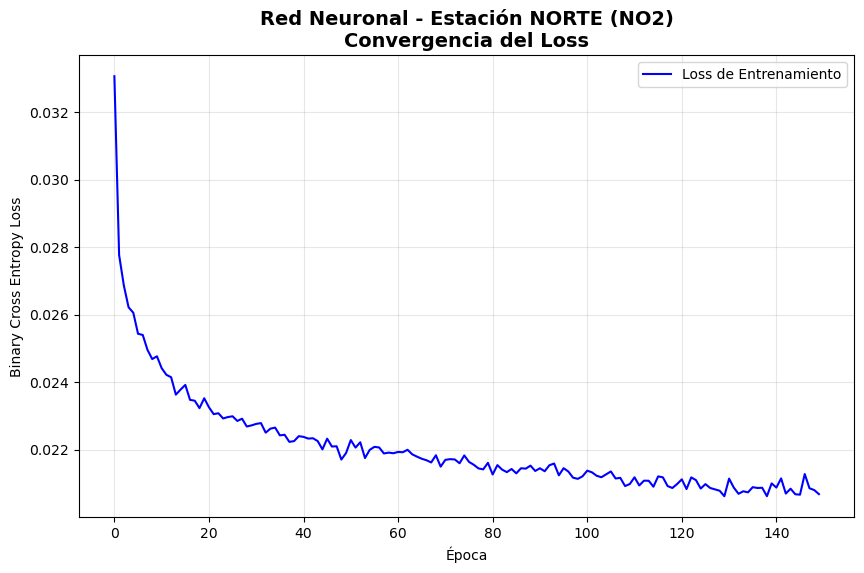

📈 ANÁLISIS DEL ENTRENAMIENTO:
Épocas totales: 150
Loss inicial: 0.0331
Loss final: 0.0207
Reducción del loss: 0.0124


In [55]:
# Visualizar el progreso del entrenamiento
plot_training_history(history_norte, "Red Neuronal - Estación NORTE (NO2)")

In [56]:
# Mostrar reporte de clasificación de la red neuronal
print("📊 REPORTE DE CLASIFICACIÓN - RED NEURONAL NORTE:")
print("=" * 60)
import pandas as pd
df_report_nn = pd.DataFrame(nn_report_norte).T
print(df_report_nn)

📊 REPORTE DE CLASIFICACIÓN - RED NEURONAL NORTE:
              precision    recall  f1-score      support
0              0.963903  0.848760  0.902675  5726.000000
1              0.344932  0.714734  0.465306   638.000000
accuracy       0.835324  0.835324  0.835324     0.835324
macro avg      0.654418  0.781747  0.683990  6364.000000
weighted avg   0.901850  0.835324  0.858828  6364.000000


## Ejemplo 2: Red Neuronal para Estación NORESTE - PM2.5

In [57]:
# Entrenar red neuronal para estación NORTE con características de hora
nn_model_noreste, nn_report_noreste, scaler_noreste, history_noreste = neural_model_station(
    df=dfs["NORESTE"],
    contaminant_idx=7,  # PM2.5
    wind_dir_idx=15,
    wind_speed_idx=14,
    rh_idx=10,
    include_hour_features=True,  # 🕒 Incluir características de hora
    hidden1_size=64,
    hidden2_size=32,
    dropout_rate=0.3,
    learning_rate=0.001,
    epochs=150,
    batch_size=32,
    verbose=True
)

🎮 Usando dispositivo: cpu
🕒 Agregadas 23 características de hora
Umbral crítico: 36.590
Variables utilizadas: ['Wind_sin', 'Wind_cos', 'Wind_Speed', 'Humidity', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6', 'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12', 'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18', 'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23']
Total de características: 27
Distribución objetivo: [19089  2123]
Ratio desbalance: 9.0:1
Shape de X: (21212, 27)

🚀 Iniciando entrenamiento con Focal Loss por 150 épocas...
   Alpha: 0.25, Gamma: 2.0
   Input size: 27 características


Entrenando:  13%|█▎        | 20/150 [00:05<00:32,  4.03it/s]

Época 20/150, Loss: 0.0277


Entrenando:  27%|██▋       | 40/150 [00:10<00:29,  3.74it/s]

Época 40/150, Loss: 0.0267


...

Época 120/150, Loss: 0.0257


Entrenando:  93%|█████████▎| 140/150 [00:35<00:02,  3.89it/s]

Época 140/150, Loss: 0.0257


Entrenando: 100%|██████████| 150/150 [00:38<00:00,  3.90it/s]

🎯 Threshold óptimo encontrado: 0.230
   Con F1 de clase crítica: 0.308
   Garantizando recall mínimo: 70.0%

✅ Entrenamiento con Focal Loss completado!
Loss final: 0.0257
Threshold óptimo: 0.230


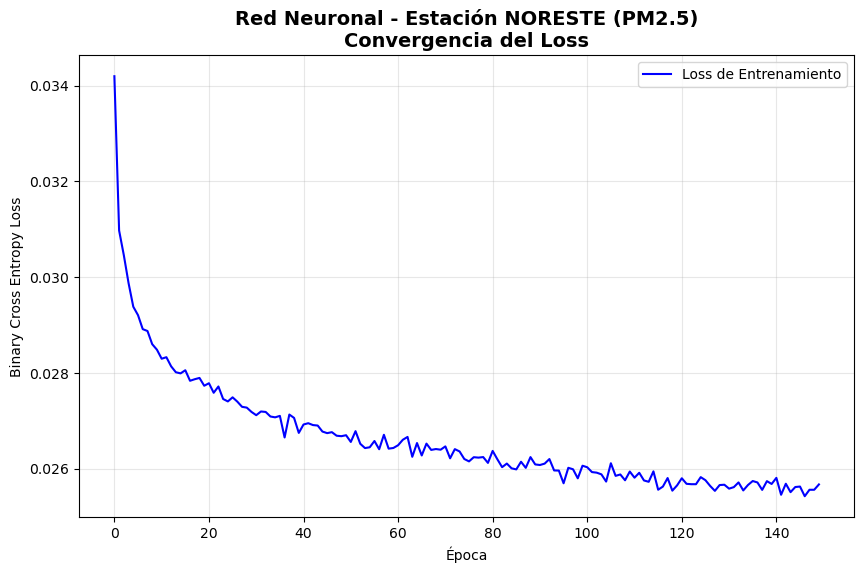

📈 ANÁLISIS DEL ENTRENAMIENTO:
Épocas totales: 150
Loss inicial: 0.0342
Loss final: 0.0257
Reducción del loss: 0.0085


In [58]:
# Visualizar el progreso del entrenamiento
plot_training_history(history_noreste, "Red Neuronal - Estación NORESTE (PM2.5)")

## Evaluación y Matriz de Confusión de las Redes Neuronales

Ahora evaluamos los modelos neurales de manera similar a como evaluaste los modelos logísticos.

In [59]:
# Para evaluar correctamente, necesitamos recrear los datos de test
# usando la misma lógica que en neural_model_station

def prepare_test_data_for_evaluation(df, contaminant_idx, wind_dir_idx=None, 
                                    wind_speed_idx=None, rh_idx=None, temp_idx=None, 
                                    threshold=None, include_hour_features=True):
    """
    Prepara los datos de test para evaluación usando la misma lógica que neural_model_station.
    Ahora incluye características de hora.
    """
    contaminant_col = df.columns[contaminant_idx]
    feature_cols = []
    data_cols = [contaminant_col]
    
    if wind_dir_idx is not None:
        wind_col = df.columns[wind_dir_idx]
        data_cols.append(wind_col)
    
    if wind_speed_idx is not None:
        speed_col = df.columns[wind_speed_idx]
        data_cols.append(speed_col)
        feature_cols.append(speed_col)
    
    if rh_idx is not None:
        rh_col = df.columns[rh_idx]
        data_cols.append(rh_col)
        feature_cols.append(rh_col)
    
    if temp_idx is not None:
        temp_col = df.columns[temp_idx]
        data_cols.append(temp_col)
        feature_cols.append(temp_col)

    # 🕒 Agregar columnas de horas
    hour_cols = []
    if include_hour_features:
        hour_cols = [col for col in df.columns if col.startswith('hour_')]
        if hour_cols:
            data_cols.extend(hour_cols)
            feature_cols.extend(hour_cols)

    data = df[data_cols].dropna()
    
    if threshold is None:
        threshold = np.percentile(data[contaminant_col], 90)
    
    data["Critical"] = (data[contaminant_col] >= threshold).astype(int)
    
    X_data = []
    
    # Variables de viento
    if wind_dir_idx is not None:
        wind_rad = np.deg2rad(data[wind_col] % 360)
        X_data.append(np.sin(wind_rad))
        X_data.append(np.cos(wind_rad))
    
    # Variables continuas (excluyendo horas)
    for col in feature_cols:
        if col not in hour_cols:
            X_data.append(data[col].values)
    
    # Variables de hora (one-hot encoded)
    if include_hour_features and hour_cols:
        for hour_col in hour_cols:
            X_data.append(data[hour_col].values)
    
    X = np.column_stack(X_data)
    y = data["Critical"].values
    
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    return X_test, y_test

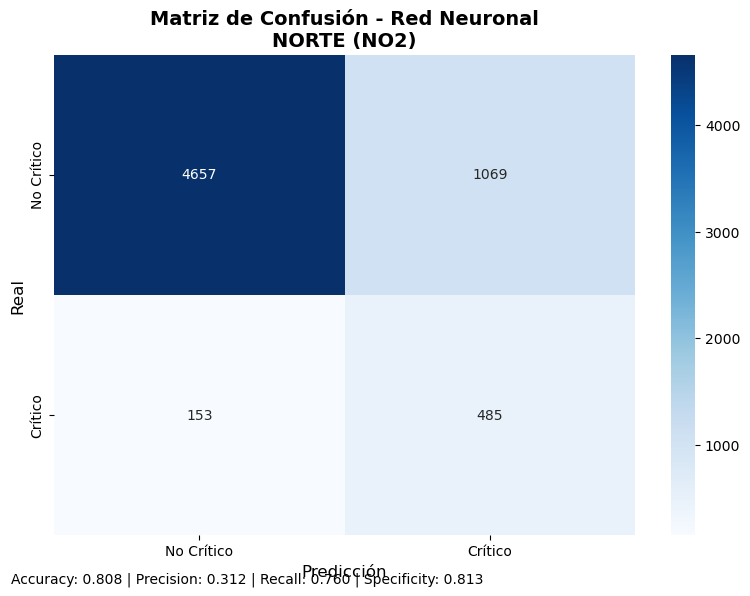

📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 4657 - Correctamente clasificados como No Críticos
Falsos Positivos (FP): 1069 - Incorrectamente clasificados como Críticos
Falsos Negativos (FN): 153 - Incorrectamente clasificados como No Críticos
Verdaderos Positivos (TP): 485 - Correctamente clasificados como Críticos

📈 MÉTRICAS:
Accuracy (Exactitud): 0.808
Precision (Precisión): 0.312
Recall (Sensibilidad): 0.760
Specificity (Especificidad): 0.813


In [60]:
# Evaluar modelo neural de NORTE
X_test_norte, y_test_norte = prepare_test_data_for_evaluation(
    dfs["NORTE"], 3, 15, 14, 10, include_hour_features=True
)

eval_results_norte = evaluate_neural_model(
    nn_model_norte, X_test_norte, y_test_norte, scaler_norte, 
    threshold=0.27, station_name="NORTE (NO2)"
)

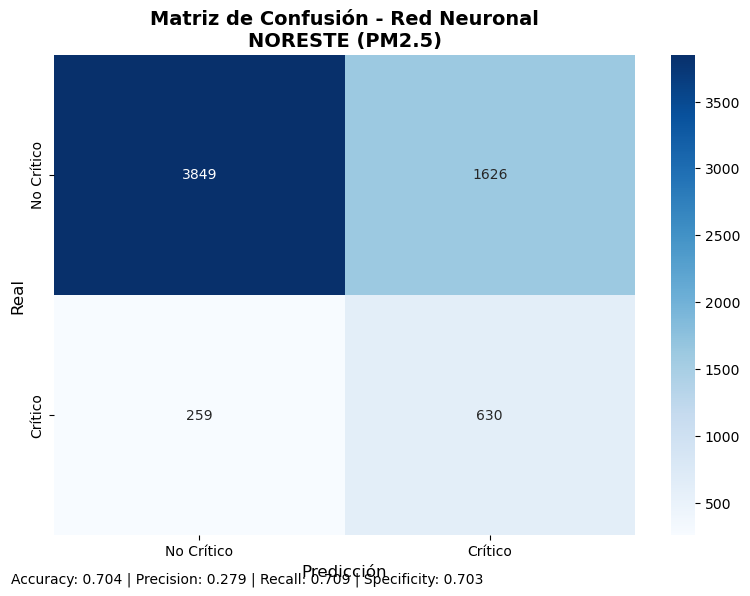

📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 3849 - Correctamente clasificados como No Críticos
Falsos Positivos (FP): 1626 - Incorrectamente clasificados como Críticos
Falsos Negativos (FN): 259 - Incorrectamente clasificados como No Críticos
Verdaderos Positivos (TP): 630 - Correctamente clasificados como Críticos

📈 MÉTRICAS:
Accuracy (Exactitud): 0.704
Precision (Precisión): 0.279
Recall (Sensibilidad): 0.709
Specificity (Especificidad): 0.703


In [61]:
# Evaluar modelo neural de NORESTE
X_test_noreste, y_test_noreste = prepare_test_data_for_evaluation(
    dfs["NORESTE"], 7, 15, 14, 10, threshold=33, include_hour_features=True
)

eval_results_noreste = evaluate_neural_model(
    nn_model_noreste, X_test_noreste, y_test_noreste, scaler_noreste, 
    threshold=0.23, station_name="NORESTE (PM2.5)"
)

## Comparación de Desempeño: Modelo Logístico vs Red Neuronal

Comparamos las métricas de ambos enfoques para ver cuál funciona mejor.

In [62]:
# Función para comparar modelos
def compare_models(logistic_report, neural_results, station_name):
    """
    Compara el desempeño entre modelo logístico y red neuronal.
    """
    print(f"🔍 COMPARACIÓN DE MODELOS - {station_name}")
    print("=" * 60)
    
    # Extraer métricas del modelo logístico
    log_accuracy = logistic_report['accuracy']
    log_precision = logistic_report['1']['precision']
    log_recall = logistic_report['1']['recall']
    log_f1 = logistic_report['1']['f1-score']
    
    # Métricas de la red neuronal
    nn_accuracy = neural_results['accuracy']
    nn_precision = neural_results['precision']
    nn_recall = neural_results['recall']
    nn_specificity = neural_results['specificity']
    
    # Calcular F1 para red neuronal
    nn_f1 = 2 * (nn_precision * nn_recall) / (nn_precision + nn_recall) if (nn_precision + nn_recall) > 0 else 0
    
    print(f"{'Métrica':<15} {'Logístico':<12} {'Red Neuronal':<15} {'Mejor':<10}")
    print("-" * 60)
    
    metrics = [
        ('Accuracy', log_accuracy, nn_accuracy),
        ('Precision', log_precision, nn_precision),
        ('Recall', log_recall, nn_recall),
        ('F1-Score', log_f1, nn_f1)
    ]
    
    for metric_name, log_val, nn_val in metrics:
        better = '🟢 NN' if nn_val > log_val else '🔵 Log' if log_val > nn_val else '🟡 Tie'
        print(f"{metric_name:<15} {log_val:<12.3f} {nn_val:<15.3f} {better}")
    
    print("\n💡 INTERPRETACIÓN:")
    if nn_accuracy > log_accuracy:
        print("✅ La red neuronal muestra mejor accuracy general")
    else:
        print("✅ El modelo logístico muestra mejor accuracy general")
    
    if nn_f1 > log_f1:
        print("✅ La red neuronal tiene mejor balance precision-recall (F1)")
    else:
        print("✅ El modelo logístico tiene mejor balance precision-recall (F1)")

In [63]:
# Comparar modelos de NORTE
compare_models(report_norte, eval_results_norte, "ESTACIÓN NORTE (NO2)")

🔍 COMPARACIÓN DE MODELOS - ESTACIÓN NORTE (NO2)
Métrica         Logístico    Red Neuronal    Mejor     
------------------------------------------------------------
Accuracy        0.815        0.808           🔵 Log
Precision       0.302        0.312           🟢 NN
Recall          0.646        0.760           🟢 NN
F1-Score        0.412        0.443           🟢 NN

💡 INTERPRETACIÓN:
✅ El modelo logístico muestra mejor accuracy general
✅ La red neuronal tiene mejor balance precision-recall (F1)


In [64]:
# Comparar modelos de NORESTE
compare_models(report_noreste, eval_results_noreste, "ESTACIÓN NORESTE (PM2.5)")

🔍 COMPARACIÓN DE MODELOS - ESTACIÓN NORESTE (PM2.5)
Métrica         Logístico    Red Neuronal    Mejor     
------------------------------------------------------------
Accuracy        0.670        0.704           🟢 NN
Precision       0.249        0.279           🟢 NN
Recall          0.678        0.709           🟢 NN
F1-Score        0.365        0.401           🟢 NN

💡 INTERPRETACIÓN:
✅ La red neuronal muestra mejor accuracy general
✅ La red neuronal tiene mejor balance precision-recall (F1)


## Optimización de Hiperparámetros

Puedes experimentar con diferentes configuraciones para mejorar el desempeño de la red neuronal.